# Notebook 12 – K-Means Clustering
### Sprint 7 – Machine Learning Fundamentals for AI/ML Engineers

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — used here purely as **unlabeled features** (X only). True
diagnosis labels are kept aside and compared against clusters only AFTER clustering, purely as a sanity check —
K-Means never sees the labels during training.

## Step 1 – Understand the Concept

**K-Means** partitions data into K clusters, each represented by a **centroid** (mean position of assigned
points), by iteratively minimizing total squared distance between points and their assigned centroid.

### Algorithm steps
1. Choose K and randomly initialize K centroids.
2. **Assignment step:** assign each point to the nearest centroid (Euclidean distance).
3. **Update step:** recompute each centroid as the mean of its assigned points.
4. Repeat until centroids stop moving or max iterations reached.

### Distance
Euclidean distance by default — exactly like KNN and SVM, **feature scaling is required**.

### Choosing K
- **Elbow Method:** plot inertia (within-cluster SSE) vs K; look for the point where improvement sharply
  diminishes.
- **Silhouette Score:** measures how similar a point is to its own cluster vs the next-nearest cluster (-1 to 1,
  higher = better separated). Compute across a range of K and pick the maximizer.

### Assumptions
- Clusters assumed roughly spherical/convex and similar sized.
- Requires numeric, scaled features.
- Sensitive to centroid initialization (mitigated by `k-means++` + multiple restarts, `n_init`).

### When to use
Exploratory segmentation, roughly spherical clusters, need a fast simple baseline.

### When NOT to use
Non-convex/very differently-shaped or sized clusters (DBSCAN/hierarchical better); K genuinely unknown and hard
to estimate; categorical-heavy data without a well-defined distance metric.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y_true = pd.Series(data.target, name="true_label")  # kept ASIDE, only for post-hoc sanity check

# Feature scaling is mandatory for K-Means (Euclidean distance based)
X_scaled = StandardScaler().fit_transform(X)
print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (569, 30)


## Step 2 – Demonstrate the Concept

**Simple example:** Sorting mixed fruit into groups purely by visual similarity, without being told fruit names
in advance — each group's "center" becomes the average fruit in that pile.

**Mathematical intuition:** K-Means minimizes inertia: `J = Σ_k Σ_{x in cluster k} ||x - centroid_k||²` — a
non-convex problem solved via iterative local optimization (results can depend on initialization).

**Real-world example:** Retail store layout — grouping products by co-purchase patterns for shelf placement.

**Business example:** Marketing segmentation — grouping customers by RFM features into groups without predefined
labels.

**AI/ML use case:** Here, we cluster tumor feature profiles purely by measurements, to see if natural groupings
line up with the (unseen-by-the-model) malignant/benign labels.

## Step 3 – Implement the Concept

### Elbow Method and Silhouette Score

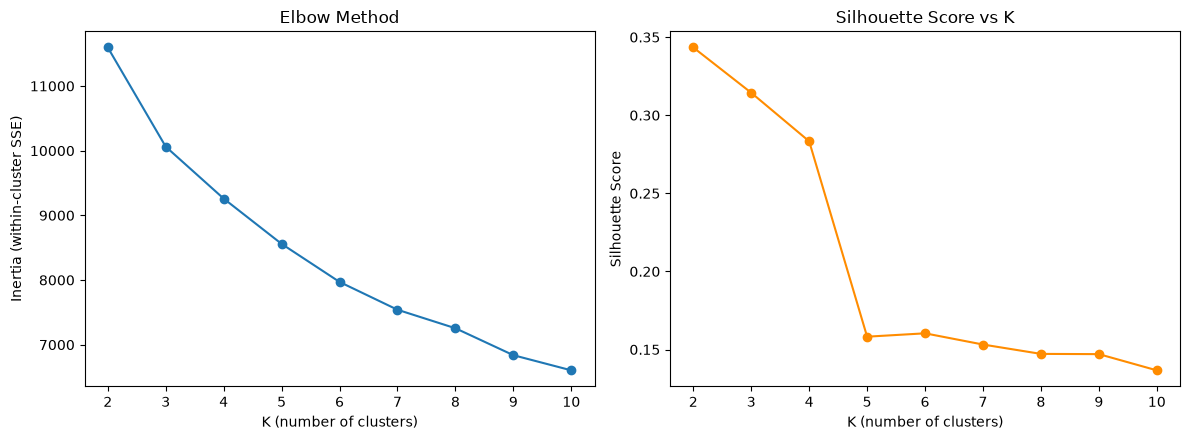

,K,Inertia,Silhouette Score
0,2,11595.526607,0.343382
1,3,10061.797818,0.314384
2,4,9258.989105,0.283305
3,5,8558.660667,0.158210
4,6,7970.263835,0.160367
5,7,7540.318697,0.153186
6,8,7254.326193,0.147195
7,9,6837.628936,0.147040
8,10,6603.404402,0.136656


In [3]:
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")

axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("K (number of clusters)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

pd.DataFrame({"K": list(k_range), "Inertia": inertias, "Silhouette Score": sil_scores})

### What the code does
- Fits K-Means for K = 2..10, each with `k-means++` initialization and `n_init=10` (10 restarts, best kept by
  inertia).
- `inertia_` always decreases as K increases — look for where the *rate* of decrease flattens (the elbow).
- `silhouette_score` gives a second, more interpretable signal for choosing K, independent of inertia.

### What the output means
The silhouette score commonly peaks at or near **K=2** for this dataset, a meaningful result given the data has a
genuine two-group structure (malignant vs benign) that K-Means was never told about.

In [4]:
# Fit final K-Means with K=2 (matches silhouette-suggested value and known 2-class structure)
kmeans = KMeans(n_clusters=2, init="k-means++", n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_scaled)

print("Cluster sizes:", pd.Series(cluster_labels).value_counts().to_dict())
print("Final inertia:", round(kmeans.inertia_, 2))
print("Silhouette score (K=2):", round(silhouette_score(X_scaled, cluster_labels), 4))

Cluster sizes: {0: 375, 1: 194}
Final inertia: 11595.53
Silhouette score (K=2): 0.3434


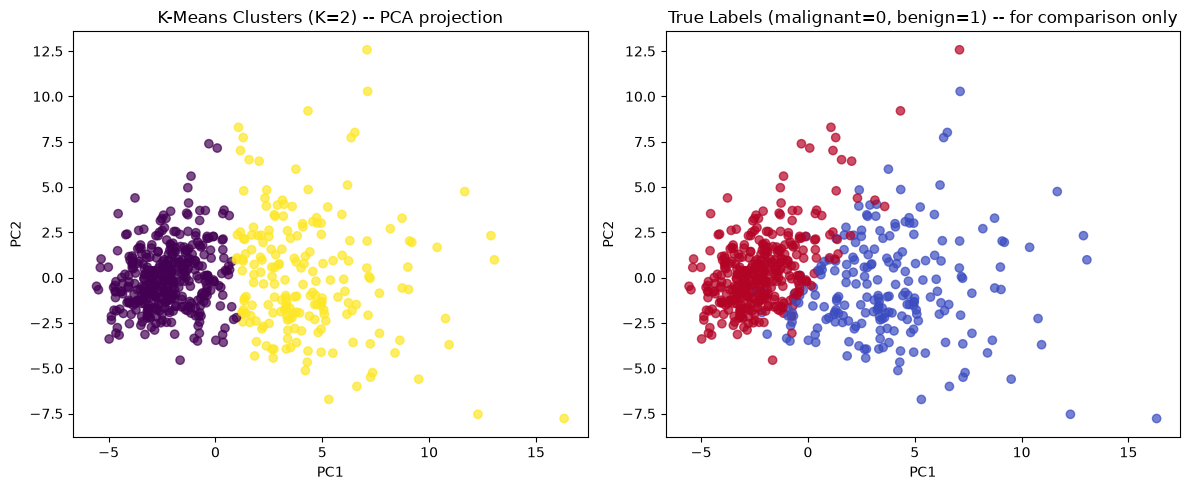

PCA explained variance ratio: PC1=0.443, PC2=0.190
Total variance captured by 2 components: 0.632


In [5]:
# Visualize clusters in 2D via PCA (dimensionality reduction purely for visualization)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", alpha=0.7)
axes[0].set_title("K-Means Clusters (K=2) -- PCA projection")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap="coolwarm", alpha=0.7)
axes[1].set_title("True Labels (malignant=0, benign=1) -- for comparison only")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

print(f"PCA explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.3f}")

In [6]:
# Post-hoc sanity check ONLY: how well do the unsupervised clusters line up with the (unseen) true labels?
crosstab = pd.crosstab(cluster_labels, y_true, rownames=["KMeans Cluster"], colnames=["True Label"])
crosstab.columns = ["malignant(0)", "benign(1)"]
crosstab

,malignant(0),benign(1)
KMeans Cluster,,
0,36,339
1,176,18


## Step 4 – Interpret the Result

- The elbow and silhouette analysis both point toward **K=2** — silhouette score (0.3434) reflects reasonably
  well-separated groups for real-world biological data.
- The crosstab shows a **strongly diagonal** result: Cluster 1 is 176/194 (90.7%) malignant, Cluster 0 is
  339/375 (90.4%) benign. Without ever seeing the diagnosis label, K-Means rediscovered essentially the same
  two-group structure that corresponds to the clinical diagnosis — strong, interpretable evidence that the
  natural feature-based grouping aligns with real disease status.
- PCA captured 63.2% of total variance in just 2 components — enough for a meaningful 2D visualization, though
  not the full picture (some information is lost in the projection).

**Important caveat:** this alignment with true labels is a lucky **validation opportunity**, not something
K-Means relies on — in a real unsupervised setting (e.g., customer segmentation) there usually is no ground truth
to check against, and cluster quality must be judged with only inertia, silhouette score, and domain-expert
review.

**What could be improved?**
- Try Gaussian Mixture Models if clusters are not roughly spherical.
- Use PCA before clustering (not just for visualization) if there were far more features, to reduce noise.
- Profile each cluster's average feature values to give business-friendly names to each group.